# Diabetes Risk Prediction Using Machine Learning Algorithms

## Project Title

This notebook presents a clean exploratory data analysis workflow for the project **Diabetes Risk Prediction Using Machine Learning Algorithms**. The analysis focuses on understanding the dataset structure, checking basic data quality, and exploring important health, lifestyle, and demographic indicators before any machine learning model is trained.

## Introduction

Diabetes risk prediction is a binary classification problem in which health-related indicators are used to distinguish between individuals with no diabetes and individuals with diabetes or elevated diabetes risk. The dataset used in this project contains survey-based indicators that describe medical history, lifestyle behaviors, general health, and socioeconomic characteristics.

This notebook is limited to data loading, overview, data quality assessment, and exploratory data analysis. Model training and evaluation are intentionally excluded from this stage.

## Import Libraries

The following libraries support the exploratory analysis. `pandas` is used for tabular data manipulation, `numpy` for numerical operations, and `matplotlib` and `seaborn` for visualizing distributions and relationships among variables.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

figures_dir = Path("../reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## Load Dataset

The dataset is loaded from the raw data folder using a relative path from the notebook directory. After loading the data, a categorical target label column named `Diabetes_Status` is created to make the target distribution and grouped visualizations clear and reliable.

In [2]:
dataset_path = Path("../data/raw/diabetes_binary_health_indicators_BRFSS2015.csv")
df = pd.read_csv(dataset_path)

df["Diabetes_Status"] = df["Diabetes_binary"].astype(int).map({
    0: "No diabetes",
    1: "Diabetes or risk"
})

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_Status
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,No diabetes
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,No diabetes
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,No diabetes
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,No diabetes
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,No diabetes


The first five records provide an initial view of the available columns, including the binary target variable and the health indicator features.

## Dataset Overview

This section examines the structure of the dataset, including its dimensions, column names, and data types. These checks provide a foundation for later preprocessing and modeling decisions.

In [3]:
df.shape

(253680, 23)

In [4]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Diabetes_Status'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

## Data Quality Checks

Before performing exploratory analysis, the dataset is checked for missing values, duplicated rows, and general numerical characteristics. These checks help identify potential preprocessing needs.

In [6]:
missing_values = df.isna().sum().to_frame(name="missing_count")
missing_values

,missing_count
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [7]:
duplicated_rows = df.duplicated().sum()
duplicated_rows

np.int64(24206)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


## Exploratory Data Analysis

Exploratory data analysis is used to study the target distribution and selected predictor variables. The figures generated in this section are saved to the `reports/figures` directory for later reporting.

The target variable is summarized as both counts and percentages. This helps determine whether the binary classification task contains a balanced or imbalanced class distribution.

In [9]:
target_counts = df["Diabetes_Status"].value_counts().reindex(
    ["No diabetes", "Diabetes or risk"],
    fill_value=0
)

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": (target_counts / len(df) * 100).round(2)
})

target_distribution

,count,percentage
Diabetes_Status,,
No diabetes,218334,86.07
Diabetes or risk,35346,13.93


The count plot below visualizes the number of records in each target class using the categorical `Diabetes_Status` label.

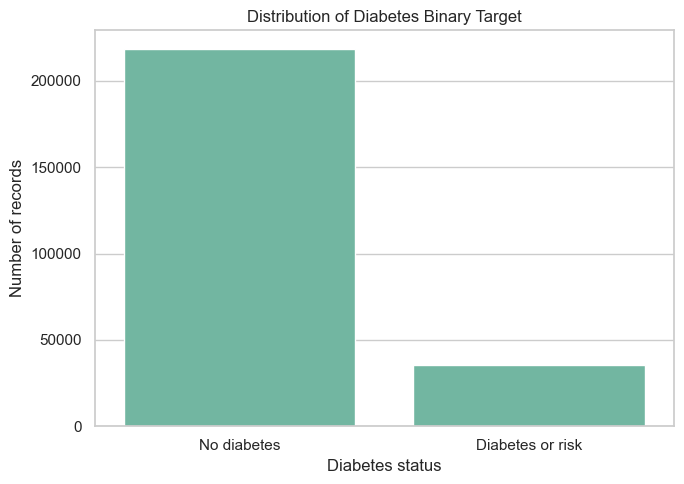

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Diabetes_Status",
    order=["No diabetes", "Diabetes or risk"],
    ax=ax
)

ax.set_title("Distribution of Diabetes Binary Target")
ax.set_xlabel("Diabetes status")
ax.set_ylabel("Number of records")

fig.tight_layout()
fig.savefig(figures_dir / "diabetes_binary_countplot.png", dpi=300, bbox_inches="tight")
plt.show()

A correlation heatmap is used to inspect linear relationships among numeric variables. Although correlation does not imply causation, it can help identify variables that may be useful for later modeling.

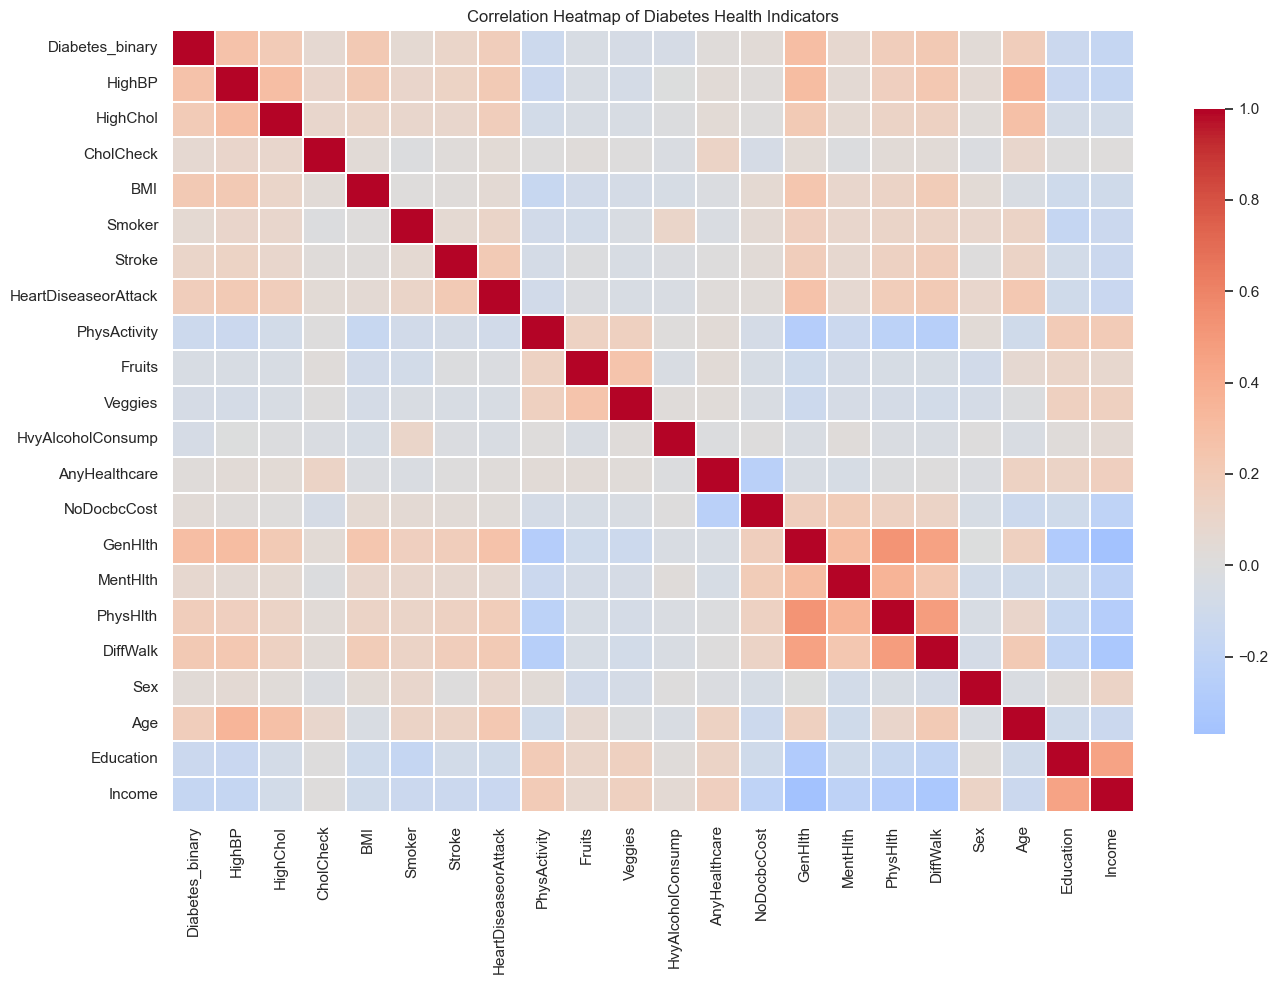

In [11]:
correlation_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Correlation Heatmap of Diabetes Health Indicators")
fig.tight_layout()
fig.savefig(figures_dir / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

Histograms are created for selected important variables: `BMI`, `GenHlth`, `Age`, `Income`, and `Education`. These variables represent body composition, self-reported health status, age category, and socioeconomic indicators.

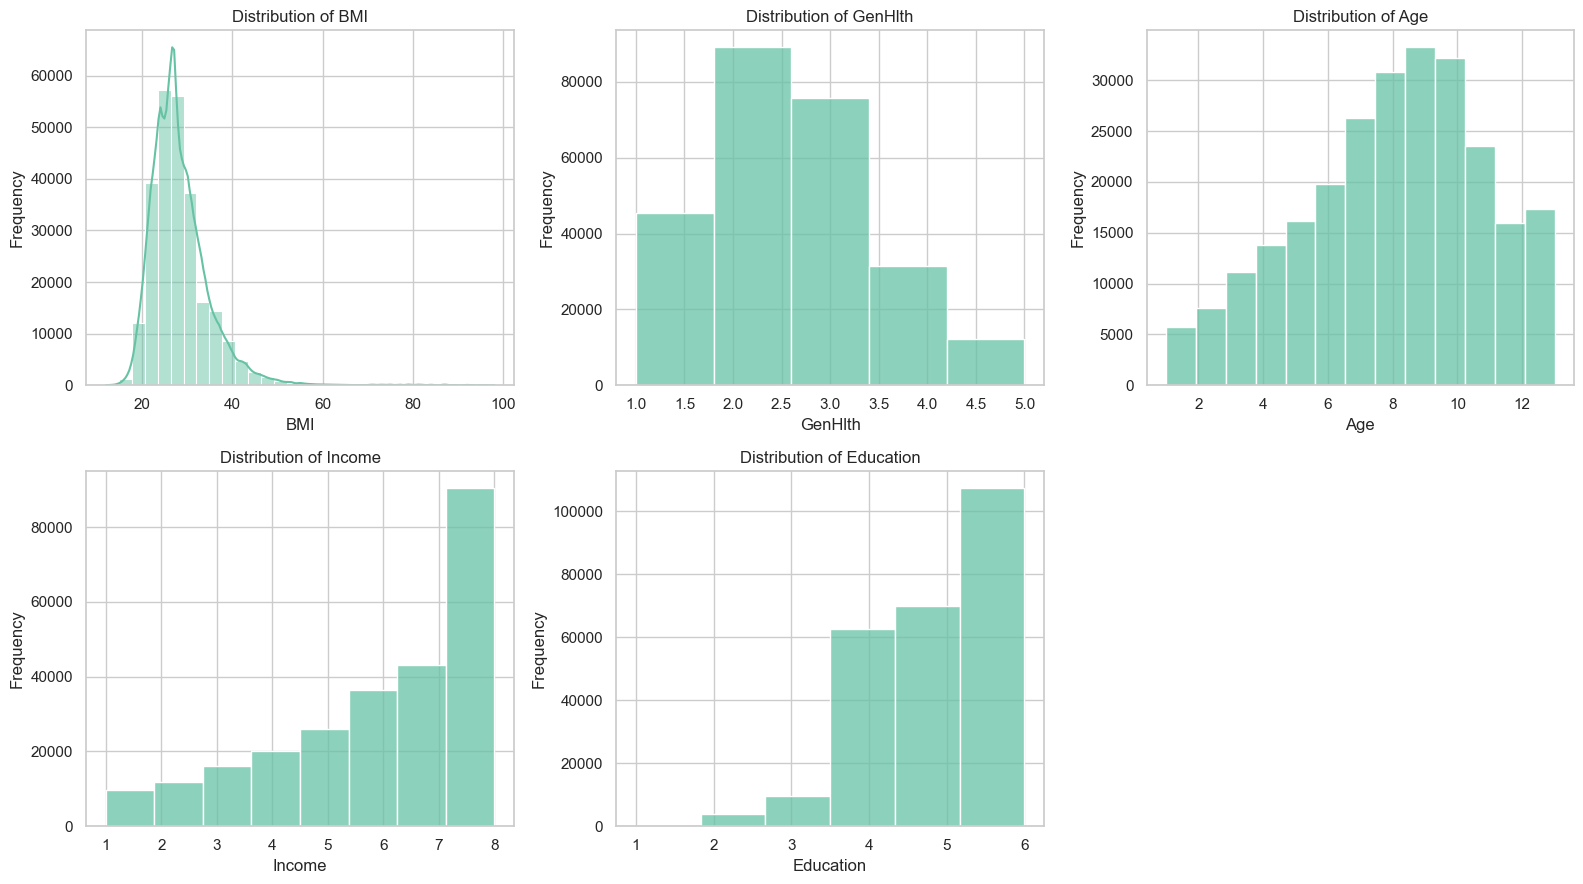

In [12]:
important_variables = ["BMI", "GenHlth", "Age", "Income", "Education"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, column in zip(axes, important_variables):
    bins = 30 if column == "BMI" else int(df[column].nunique())
    sns.histplot(
        data=df,
        x=column,
        bins=bins,
        kde=(column == "BMI"),
        ax=ax
    )
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

axes[-1].axis("off")
fig.tight_layout()
fig.savefig(figures_dir / "important_variable_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

Boxplots compare the distributions of `BMI`, `GenHlth`, and `Age` across the two diabetes status groups. This helps identify visible differences between individuals with no diabetes and individuals with diabetes or diabetes risk.

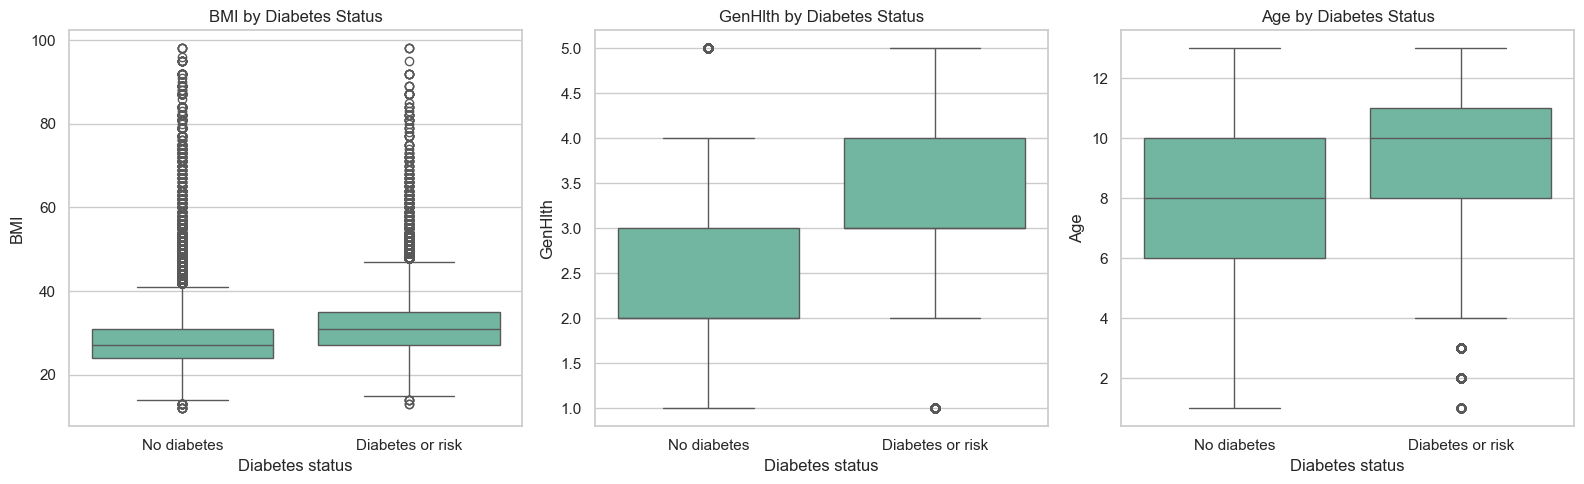

In [13]:
comparison_variables = ["BMI", "GenHlth", "Age"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, column in zip(axes, comparison_variables):
    sns.boxplot(
        data=df,
        x="Diabetes_Status",
        y=column,
        order=["No diabetes", "Diabetes or risk"],
        ax=ax
    )
    ax.set_title(f"{column} by Diabetes Status")
    ax.set_xlabel("Diabetes status")
    ax.set_ylabel(column)

fig.tight_layout()
fig.savefig(figures_dir / "boxplots_by_diabetes_status.png", dpi=300, bbox_inches="tight")
plt.show()

Grouped descriptive statistics provide a numerical complement to the boxplots by summarizing the central tendency and variability of selected variables for each target class.

In [14]:
df.groupby("Diabetes_Status")[comparison_variables].agg(["mean", "median", "std"]).round(2)

BMI              GenHlth                Age             
                   mean median   std    mean median   std  mean median   std
Diabetes_Status                                                             
Diabetes or risk  31.94   31.0  7.36    3.29    3.0  1.01  9.38   10.0  2.33
No diabetes       27.81   27.0  6.29    2.39    2.0  1.02  7.81    8.0  3.10

## Machine Learning Model Development

This section develops and compares several supervised machine learning algorithms for diabetes risk prediction. The target variable is `Diabetes_binary`, where `0` represents no diabetes and `1` represents diabetes or diabetes risk.

Because diabetes risk prediction is a health-related classification task, recall is especially important. A false negative may incorrectly classify a person at risk as not at risk, which can reduce the opportunity for early screening or preventive action. For this reason, recall, F1-score, and ROC-AUC are emphasized alongside accuracy.

### Prepare Features and Target

The feature matrix `X` is created by removing the target column and the human-readable target label column. The target vector `y` is converted to integer values for classification.

In [15]:
X = df.drop(columns=["Diabetes_binary", "Diabetes_Status"], errors="ignore")
y = df["Diabetes_binary"].astype(int)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

y.value_counts(normalize=True).rename("class_proportion").to_frame()

Feature matrix shape: (253680, 21)
Target vector shape: (253680,)


,class_proportion
Diabetes_binary,
0,0.860667
1,0.139333


The class distribution is imbalanced, with the positive diabetes or risk class representing a smaller portion of the dataset. Therefore, accuracy alone is not sufficient for evaluation. Recall measures how many actual positive cases are detected, while F1-score balances precision and recall. ROC-AUC summarizes the model's ranking ability across classification thresholds.

SMOTE is not used at this stage. Instead, class weighting is applied where supported by the algorithm. Gradient boosting receives balanced sample weights, and XGBoost, if available, uses a positive-class scale weight. KNN does not support class weights directly.

### Train-Test Split

The dataset is split into training and testing sets using stratification to preserve the target class proportions in both subsets.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("Testing target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set shape: (202944, 21)
Testing set shape: (50736, 21)
Training target distribution:
Diabetes_binary
0    0.8607
1    0.1393
Name: proportion, dtype: float64
Testing target distribution:
Diabetes_binary
0    0.8607
1    0.1393
Name: proportion, dtype: float64


### Scaling Strategy and Model Selection

Standardization is required for distance-based and linear models because their performance can be affected by feature scale. Logistic Regression and K-Nearest Neighbors are trained inside pipelines that include `StandardScaler`. Tree-based models are trained on the original feature values because they do not require feature scaling.

A regular kernel SVM is not included because the dataset contains more than 250,000 records and standard SVM training can be computationally expensive at this scale. A linear SVM or SGD-based approximation may be considered in a later experiment, but this notebook focuses on the requested baseline models.

In [17]:
from time import perf_counter

import joblib
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1))
    ]),
    "Decision Tree Classifier": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42,
        max_depth=10
    ),
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting Classifier": GradientBoostingClassifier(
        random_state=42,
        n_estimators=75,
        learning_rate=0.1,
        max_depth=3
    ),
}

xgboost_available = False
try:
    from xgboost import XGBClassifier

    negative_count = (y_train == 0).sum()
    positive_count = (y_train == 1).sum()
    scale_pos_weight = negative_count / positive_count

    models["XGBoost Classifier"] = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    )
    xgboost_available = True
except Exception as exc:
    print(f"XGBoost is not available and will be skipped: {exc}")

print("Models prepared for training:")
for model_name in models:
    print(f"- {model_name}")

Models prepared for training:
- Logistic Regression
- K-Nearest Neighbors
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier
- XGBoost Classifier


### Model Training and Evaluation

Each model is trained on the training set and evaluated on the held-out test set. The comparison uses accuracy, precision, recall, F1-score, and ROC-AUC. The model comparison table is saved for reporting.

KNN can be computationally expensive on a dataset of this size because prediction requires distance comparisons. To keep the notebook practical while still including KNN, KNN is trained on a stratified subset of the training data. The other models are trained on the full training set.

In [18]:
results = []
trained_models = {}
predictions = {}
prediction_scores = {}

KNN_MAX_TRAIN_ROWS = 10000

for model_name, model in models.items():
    print(f"Training {model_name}...")
    start_time = perf_counter()

    X_fit = X_train
    y_fit = y_train

    if model_name == "K-Nearest Neighbors" and len(X_train) > KNN_MAX_TRAIN_ROWS:
        X_fit, _, y_fit, _ = train_test_split(
            X_train,
            y_train,
            train_size=KNN_MAX_TRAIN_ROWS,
            random_state=42,
            stratify=y_train
        )

    fit_kwargs = {}
    if model_name == "Gradient Boosting Classifier":
        fit_kwargs["sample_weight"] = compute_sample_weight(class_weight="balanced", y=y_fit)

    try:
        model.fit(X_fit, y_fit, **fit_kwargs)
    except Exception as exc:
        if model_name == "XGBoost Classifier":
            print(f"Skipping XGBoost because training failed: {exc}")
            continue
        raise

    y_pred = model.predict(X_test)

    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)

    roc_auc = roc_auc_score(y_test, y_score) if y_score is not None else np.nan
    elapsed_seconds = perf_counter() - start_time

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc,
        "Training and prediction time (seconds)": round(elapsed_seconds, 2),
    })

    trained_models[model_name] = model
    predictions[model_name] = y_pred
    if y_score is not None:
        prediction_scores[model_name] = y_score

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False).reset_index(drop=True)

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)
results_df.to_csv(reports_dir / "model_comparison_results.csv", index=False)

results_df

Training Logistic Regression...
Training K-Nearest Neighbors...
Training Decision Tree Classifier...
Training Random Forest Classifier...
Training Gradient Boosting Classifier...
Training XGBoost Classifier...


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training and prediction time (seconds)
0,Gradient Boosting Classifier,0.722505,0.306802,0.787382,0.441553,0.825644,15.03
1,Logistic Regression,0.731512,0.310749,0.761069,0.441309,0.819631,0.28
2,XGBoost Classifier,0.720238,0.305317,0.790352,0.440476,0.826131,0.59
3,Decision Tree Classifier,0.703997,0.291682,0.787240,0.425654,0.806100,0.81
4,Random Forest Classifier,0.857675,0.468543,0.160136,0.238693,0.792103,5.52
5,K-Nearest Neighbors,0.857182,0.444860,0.101004,0.164630,0.764206,2.58


The comparison table is sorted by F1-score because F1-score balances precision and recall. In diabetes risk prediction, recall is particularly important because missing actual diabetes-risk cases can be more harmful than producing some false positives.

### Best Model Evaluation and Saving

The best model is selected using the highest F1-score from the comparison table. Its classification report, confusion matrix, and ROC curve are generated to support a more detailed interpretation of performance.

In [19]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print(f"Best model based on F1-score: {best_model_name}")
print()
print(classification_report(
    y_test,
    best_predictions,
    target_names=["No diabetes", "Diabetes or risk"],
    zero_division=0
))

Best model based on F1-score: Gradient Boosting Classifier

                  precision    recall  f1-score   support

     No diabetes       0.95      0.71      0.82     43667
Diabetes or risk       0.31      0.79      0.44      7069

        accuracy                           0.72     50736
       macro avg       0.63      0.75      0.63     50736
    weighted avg       0.86      0.72      0.76     50736



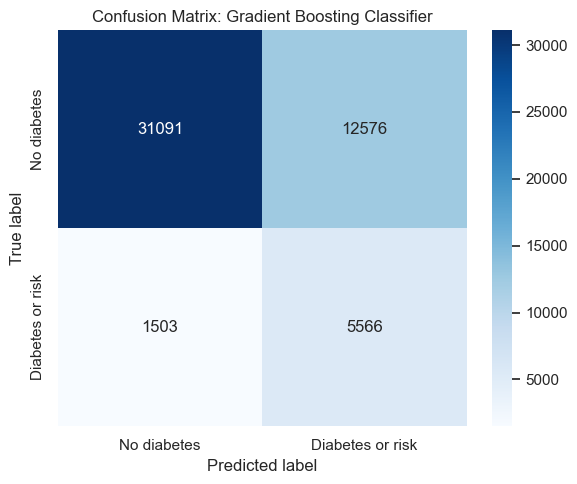

In [20]:
cm = confusion_matrix(y_test, best_predictions)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No diabetes", "Diabetes or risk"],
    yticklabels=["No diabetes", "Diabetes or risk"],
    ax=ax
)

ax.set_title(f"Confusion Matrix: {best_model_name}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

fig.tight_layout()
fig.savefig(figures_dir / "best_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

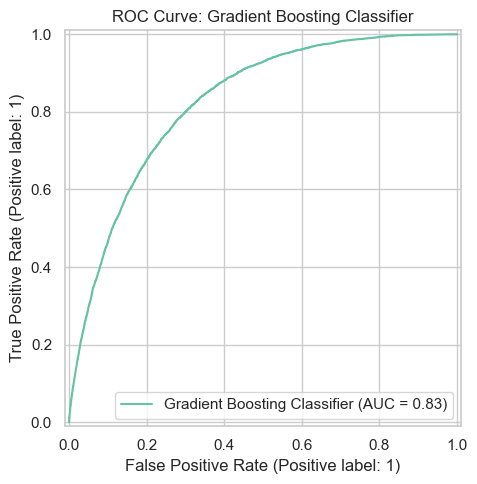

In [21]:
if best_model_name in prediction_scores:
    fig, ax = plt.subplots(figsize=(7, 5))
    RocCurveDisplay.from_predictions(
        y_test,
        prediction_scores[best_model_name],
        name=best_model_name,
        ax=ax
    )
    ax.set_title(f"ROC Curve: {best_model_name}")
    fig.tight_layout()
    fig.savefig(figures_dir / "best_model_roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print(f"ROC curve was not generated because {best_model_name} does not provide probability scores or decision scores.")

In [22]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

best_model_path = models_dir / "best_diabetes_model.pkl"
joblib.dump(best_model, best_model_path)

print(f"Best model saved to: {best_model_path}")
print(f"Model comparison results saved to: {reports_dir / 'model_comparison_results.csv'}")

Best model saved to: ..\models\best_diabetes_model.pkl
Model comparison results saved to: ..\reports\model_comparison_results.csv


The saved model can be reused later for deployment or inference. However, this result should still be interpreted as an educational machine learning experiment rather than a medical diagnostic system. Further validation, threshold tuning, and clinical review would be required before any real-world health-related use.

## Initial Observations

The dataset contains health, lifestyle, and demographic indicators suitable for a binary classification task. The target label column `Diabetes_Status` makes the two classes more interpretable in tables and visualizations.

The exploratory analysis shows that class distribution, BMI, general health, age category, income, and education should be considered carefully during preprocessing and model evaluation. Because the diabetes-risk class is smaller than the no-diabetes class, recall, F1-score, and ROC-AUC provide more informative evaluation than accuracy alone.

The machine learning section trains and compares several baseline classifiers, saves the model comparison results, and stores the best-performing model for later use. The results should be interpreted for educational purposes only and not as medical advice.